## **Figure-S17**

In [1]:
import pandas as pd
import polars as pl
from collections import defaultdict
import sys
import numpy as np
import os
import re
from functools import reduce

import matplotlib.pyplot as plt
import matplotlib as mpl
from matplotlib.ticker import FixedLocator
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.lines import Line2D

sys.path.append("../../scripts")

from figure_utils import *

In [2]:
print("Pandas Version", pd.__version__)
print("Polars Version", pl.__version__)
print("numpy Version", np.__version__)
print("matplotlib version", mpl.__version__)
print("seaborn version", sns.__version__)
print("Python Version", sys.version)

Pandas Version 2.2.3
Polars Version 1.28.1
numpy Version 2.2.2
matplotlib version 3.10.0
seaborn version 0.13.2
Python Version 3.12.4 (main, Jun  7 2024, 23:47:47) [GCC 13.3.0]


In [3]:
names = dict(silico='in-silico',
             bruker='timsTOF, 2024',
             diatracer='Direct')

condition = dict(orig='Initial', refined='Reference-based')

#### **Load Data - DIA-NN**

In [4]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'-(\d+pg)-', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderDiann(diann_dir, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {str(i):defaultdict(dict) for i in range(1,10) }

    # Define custom sort order for dilutions
    dilution_order = ["100pg", "250pg", "500pg", "1000pg", '2500pg', '5000pg']

    # Get all dilution directories within diann directory
    dilution_dirs = []
    if os.path.isdir(diann_dir):
        dilution_dirs = [d for d in os.listdir(diann_dir) 
                        if os.path.isdir(os.path.join(diann_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(diann_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            lib_dirs = [d for d in os.listdir(replicate_path) 
                       if os.path.isdir(os.path.join(replicate_path, d))
                       and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                # Path to report.tsv
                report_path = os.path.join(replicate_path, lib_dir, "report.tsv")

                lib_dilution = extract_lib_info(lib_dir)

                # Check if file exists
                if os.path.exists(report_path):
                    try:
                        # Call getPrecursorSetDiann function
                        result = getPrecursorSetDiann(report_path, **kwargs)

                        # Store both the result and the library name
                        rslts[replicate][f'Reconstructed (Reference = {lib_dilution})'] = result

                        print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
                    except Exception as e:
                        print(f"Error processing {report_path}: {str(e)}")
                else:
                    print(f"Missing report.tsv file in {os.path.join(replicate_path, lib_dir)}")
    return rslts


def appendOriginalResultsDiann(diann_dir, rslts, **kwargs):
    # Get all experiment directories within diann directory
    diann_experiment_dirs = []
    if os.path.isdir(diann_dir):
        diann_experiment_dirs = [d for d in os.listdir(diann_dir) 
                               if os.path.isdir(os.path.join(diann_dir, d)) and '_0pg' not in d and "R2024" not in d and '100pg' in d]
    
    # Process each directory
    for dir_name in diann_experiment_dirs:
        # Extract dilution and replicate
        dilution, replicate = extract_info(dir_name)
        
        # Path to report.tsv
        report_path = os.path.join(diann_dir, dir_name, "report.tsv")

        # Check if file exists
        if os.path.exists(report_path):
            try:
                # Call getPrecursorSertDiann function
                result = getPrecursorSetDiann(report_path, **kwargs)
                rslts[replicate][condition['orig']] = result

                print(f"Processed {dir_name} successfully (dilution: {dilution}, replicate: {replicate})")
            except Exception as e:
                print(f"Error processing {dir_name}: {str(e)}")
        else:
            print(f"Skipping {dir_name}: Missing report.tsv file")

diann = {}

diann[names['bruker']] = loadRefinedFolderDiann("../../results/SCP-Bruker-Lib-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-Bruker-Library-Analysis/diann/", diann[names['bruker']])

diann[names['silico']] = loadRefinedFolderDiann("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/diann")
appendOriginalResultsDiann("../../results/SCP-PeptDeep-NoMods-Analysis/diann/", diann[names['silico']])

diann[names['diatracer']] = loadRefinedFolderDiann("../../results/SCP-diaTracer-Refined-Analysis/diann/", infer_schema_length=10000)
appendOriginalResultsDiann("../../results/SCP-diaTracer-Analysis/diann", diann[names['diatracer']], infer_schema_length=10000)

../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-5000pg-rep2_lib/report.tsv
Processed 100pg rep 2 | lib dilution 5000pg | lib directory 2025-06-17-Refine-BrukerLib-5000pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-2500pg-rep2_lib/report.tsv
Processed 100pg rep 2 | lib dilution 2500pg | lib directory 2025-06-17-Refine-BrukerLib-2500pg-rep2_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-1000pg-rep3_lib/report.tsv
Processed 100pg rep 2 | lib dilution 1000pg | lib directory 2025-06-17-Refine-BrukerLib-1000pg-rep3_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/diann/100pg/HeLa02DDM_100pg_5x3_PyDIA_2_S1-C5_1_1631/2025-06-17-Refine-BrukerLib-250pg-rep1_lib/report.tsv
Processed 100pg rep 2 | lib dilution 250pg | lib directory 2025-06-17-Ref

#### **Load Data - OSW**

In [5]:
# Function to extract dilution and replicate from directory name
def extract_info(dirname: str) -> tuple:
    # Match patterns like 100ng_HeLa_Py3_DIA_1_... (replicate number after DIA_)
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    replicate_match = re.search(r'PyDIA_(\d+)_', dirname)
    
    dilution = dilution_match.group(1) if dilution_match else "unknown"
    replicate = replicate_match.group(1) if replicate_match else "unknown"
    
    return dilution, replicate


def extract_lib_info(dirname: str):
    dilution_match = re.search(r'_(\d+pg)_', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def extract_lib_info_alt(dirname: str):
    dilution_match = re.search(r'(\d+pg)', dirname)
    
    return dilution_match.group(1) if dilution_match else "unknown"

def loadRefinedFolderOSW(osw_dir, pyprophet_folder = 'pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', alt_lib_dir=False, **kwargs):
    # Dictionary to store results by dilution and replicate
    rslts = {str(i):defaultdict(dict) for i in range(1,10) }

    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.match(r'100pg', d)]
    
    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        # Get all replicate directories within this dilution directory
        replicate_dirs = [d for d in os.listdir(dilution_path) 
                         if os.path.isdir(os.path.join(dilution_path, d))]

        for replicate_dir in replicate_dirs:
            replicate_path = os.path.join(dilution_path, replicate_dir)

            # Extract replicate number
            _, replicate = extract_info(replicate_dir)

            # Look for library directories (ending with _lib)
            if alt_lib_dir:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                        if os.path.isdir(os.path.join(replicate_path, d))
                        and d.startswith('lib')]
            else:
                lib_dirs = [d for d in os.listdir(replicate_path) 
                           if os.path.isdir(os.path.join(replicate_path, d))
                           and d.endswith('_lib')]

            for lib_dir in lib_dirs:
                if not '100pg' in lib_dir: # do not show the MBR level (100pg with 100pg) because not everything has this
                    # Path to report.tsv
                    report_path = os.path.join(replicate_path, lib_dir, pyprophet_folder, replicate_dir + ".oswpq/" )
                    
                    if alt_lib_dir:
                        lib_dilution = extract_lib_info_alt(lib_dir)
                    else:
                        lib_dilution = extract_lib_info(lib_dir)

                    # Check if file exists, if not use pyprophet fallback
                    if not os.path.exists(report_path):
                        report_path = os.path.join(replicate_path, lib_dir, pyprophet_fallback, replicate_dir + ".oswpq/" )

                    rslts[replicate][f'Reconstructed (Reference = {lib_dilution})'] = getPrecursorSet_oswpq(report_path)
                    print(f"Processed {dilution_dir} rep {replicate} | lib dilution {lib_dilution} | lib directory {lib_dir}")
    return rslts

def appendOriginalResultsOSW(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        dilution, replicate = extract_info(dilution_dir)
        if dilution == '0':
            continue
        report_path = os.path.join(osw_dir, dilution_dir, pyprophet_folder, dilution_dir + ".oswpq")
        
        # Check if file exists, if not use pyprophet fallback
        if not os.path.exists(report_path):
            report_path = os.path.join(osw_dir, dilution_dir, pyprophet_fallback, dilution_dir + ".oswpq/" )
        
        rslts[replicate][condition['orig']] = getPrecursorSet_oswpq(report_path)
        print(f"Processed {dilution_dir} rep {replicate} | lib original")
        
def appendOriginalResultsOSWDiaTracer(osw_dir, rslts, pyprophet_folder='pyprophet_XGB', pyprophet_fallback='pyprophet_LDA', **kwargs):
    # Get all dilution directories within osw directory
    dilution_dirs = []
    if os.path.isdir(osw_dir):
        dilution_dirs = [d for d in os.listdir(osw_dir) 
                        if os.path.isdir(os.path.join(osw_dir, d))
                        and re.search(r'100pg', d)]

    # Process each dilution directory
    for dilution_dir in dilution_dirs:
        dilution_path = os.path.join(osw_dir, dilution_dir)

        runName_dirs = [d for d in os.listdir(os.path.join(osw_dir, dilution_dir)) 
                        if os.path.isdir(os.path.join(osw_dir, dilution_dir, d))
                        and re.search(r'pg', d)]
        
        for runName in runName_dirs: 
            dilution, replicate = extract_info(runName)

            report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_folder, runName + ".oswpq")

            # Check if file exists, if not use pyprophet fallback
            if not os.path.exists(report_path):
                report_path = os.path.join(osw_dir, dilution_dir, runName, pyprophet_fallback, runName + ".oswpq/" )
            if not os.path.exists(report_path):
                continue
                
            rslts[replicate][condition['orig']] = getPrecursorSet_oswpq(report_path)
            print(f"Processed {dilution_dir} rep {replicate} | lib original")

osw = {}

osw[names['bruker']] = loadRefinedFolderOSW("../../results/SCP-Bruker-Lib-Refined-Analysis/osw/")
appendOriginalResultsOSW("../../results/SCP-Bruker-Library-Analysis/osw/", osw[names['bruker']])

osw[names['diatracer']] = loadRefinedFolderOSW("../../results/SCP-diaTracer-Refined-Analysis/osw/", alt_lib_dir=True)
appendOriginalResultsOSWDiaTracer("../../results/SCP-diaTracer-Analysis/osw/", osw[names['diatracer']])


osw[names['silico']] = loadRefinedFolderOSW("../../results/SCP-PeptDeep-NoMods-Refined-Analysis/osw/", pyprophet_folder='pyprophet_SVM', alt_lib_dir=False)
appendOriginalResultsOSW("../../results/SCP-PeptDeep-NoMods-Analysis/osw/", osw[names['silico']], pyprophet_folder='pyprophet_SVM')

../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_250pg_5x3_PyDIA_1_S1-C7_1_1636_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 250pg | lib directory HeLa02DDM_250pg_5x3_PyDIA_1_S1-C7_1_1636_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_1000pg_5x3_PyDIA_2_S1-D2_1_1649_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 1000pg | lib directory HeLa02DDM_1000pg_5x3_PyDIA_2_S1-D2_1_1649_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716/HeLa02DDM_2500pg_5x3_PyDIA_1_S1-D4_1_1654_lib/pyprophet_XGB/HeLa02DDM_100pg_5x3_PyDIA_7_S2-C4_1_1716.oswpq/
Processed 100pg rep 7 | lib dilution 2500pg | lib directory HeLa02DDM_2500pg_5x3_PyDIA_1_S1-D4_1_1654_lib
../../results/SCP-Bruker-Lib-Refined-Analysis/osw/100pg/HeLa02DDM_100p

#### **Format For Plot**

Here going to create start plots for each library. The idea is that facet by different libraries. Show that there is a tradeoff between reproducibility and identification rates and depending on the diluti0on step that refine with that tradeoff changes. 

In [6]:
def format_for_plot(rslts):
    avg_jaccard = defaultdict(dict)
    for masterLib, rep in rslts.items():
        for lib in rslts[masterLib]['1'].keys():
            tmp = { str(i):rslts[masterLib][str(i)][lib] for i in range(1, 10) if len(rslts[masterLib][str(i)][lib]) > 0}
            avg_jaccard[masterLib][lib] = avg_jaccard_index(tmp)


    ids = defaultdict(dict)
    for masterLib, rep in rslts.items():
        for lib in rslts[masterLib]['1'].keys():
            tmp = np.array([ len(rslts[masterLib][str(i)][lib]) for i in range(1, 10) if len(rslts[masterLib][str(i)][lib]) > 0 ])
            ids[masterLib][lib] = tmp.mean()

    ids_intersect = defaultdict(dict)
    for masterLib, rep in rslts.items():
        for lib in rslts[masterLib]['1'].keys():
            tmp = [ rslts[masterLib][str(i)][lib] for i in range(1, 10) if len(rslts[masterLib][str(i)][lib]) > 0  ]
            ids_intersect[masterLib][lib] = len(reduce(set.intersection, tmp))


    avg_jaccard = pd.DataFrame(avg_jaccard).reset_index(names='Dilution Library').melt(id_vars='Dilution Library', var_name='Library', value_name='Jaccard Index')
    ids = pd.DataFrame(ids).reset_index(names='Dilution Library').melt(id_vars='Dilution Library', var_name='Library', value_name='Mean Identifications')
    ids_intersect = pd.DataFrame(ids_intersect).reset_index(names='Dilution Library').melt(id_vars='Dilution Library', var_name='Library', value_name='# Identifications In Common')
    
    return ids.merge(avg_jaccard).merge(ids_intersect)

In [7]:
diann_df = format_for_plot(diann)
osw_df = format_for_plot(osw)

In [8]:
diann_df['Software'] = 'DIA-NN'
osw_df['Software'] = 'OpenSWATH'

tog_df = pd.concat([diann_df, osw_df])

In [9]:
def create_dilution_plot(df,  
                         x='Mean Identifications', 
                         y='Jaccard Index',
                         xlabel='Average # Peptide Precursors',
                         ylabel='Jaccard Index (Reproducibility)',
                         label_fontsize=13,
                         sublabel_fontsize=11,
                         ticks_fontsize=9,
                         legend_fontsize=7,
                         legend_title_fontsize=7,
                         library_fontsize=11):
    # Set style
    plt.style.use('default')
    sns.set_palette("husl")
    
    # Define colors for each library
    library_colors = {
        names['bruker']: 'black',
        names['silico']: 'black',
        names['diatracer']: 'black'
    }
    
    dilution_colors = {
        'Reconstructed (Reference = 250pg)': '#FFC499',   # Lightest Orange
        'Reconstructed (Reference = 500pg)': '#FFAA62',   
        'Reconstructed (Reference = 1000pg)': '#FF7F0E',  
        'Reconstructed (Reference = 2500pg)': '#CC6500',  
        'Reconstructed (Reference = 5000pg)':  '#A35000'  # Darkest Orange
    } 
    
    # Calculate global axis limits BEFORE creating subplots
    all_ids = df[x]
    all_jaccard = df[y]
    
    x_padding = (all_ids.max() - all_ids.min()) * 0.1
    y_padding = (all_jaccard.max() - all_jaccard.min()) * 0.1
    
    global_xlim = (all_ids.min() - x_padding, all_ids.max() + x_padding)
    global_ylim = (0.4, 1.01)
    
    # Get unique software and libraries
    software_list = ['DIA-NN', 'OpenSWATH']  # Fixed order: DIA-NN on top, OpenSWATH on bottom
    libraries = df['Library'].unique()
    n_libs = len(libraries)
    
    # Create subplots - 2 rows (software) x n_libs columns (libraries)
    fig, axes = plt.subplots(2, n_libs, figsize=(8, 6))
    
    # Handle case where there's only one library (axes becomes 1D)
    if n_libs == 1:
        axes = axes.reshape(-1, 1)
    
    # Iterate through software (rows) and libraries (columns)
    for row, software in enumerate(software_list):
        for col, library in enumerate(libraries):
            ax = axes[row, col]
            
            # Filter data for current software and library
            subset_data = df[(df['Software'] == software) & (df['Library'] == library)].copy()
            
            if subset_data.empty:
                # If no data for this combination, hide the subplot
                ax.set_visible(False)
                continue
            
            # Get original library data
            original = subset_data[subset_data['Dilution Library'] == condition['orig']]
            dilution_data = subset_data[subset_data['Dilution Library'] != condition['orig']]
            
            # Plot original point (large, hollow circle with thick border)
            if not original.empty:
                ax.scatter(original[x], original[y], 
                          s=120, facecolors='none', edgecolors=library_colors[library], 
                          linewidth=2.5, label='Initial', zorder=5)
            
            # Plot dilution points and draw arrows
            for _, row_data in dilution_data.iterrows():
                dilution = row_data['Dilution Library']
                color = dilution_colors.get(dilution, library_colors[library])
                
                # Plot dilution point (filled circle)
                ax.scatter(row_data[x], row_data[y],
                          s=80, c=color, alpha=0.8, edgecolors='black', 
                          linewidth=1, label=dilution, zorder=4)
                
                # Draw arrow from original to dilution point (if original exists)
                if not original.empty:
                    arrow = FancyArrowPatch(
                        (original[x].iloc[0], original[y].iloc[0]),
                        (row_data[x], row_data[y]),
                        arrowstyle='->', mutation_scale=15, shrinkA=12, shrinkB=8,
                        color=color, alpha=0.7, linewidth=2, zorder=3
                    )
                    ax.add_patch(arrow)
            
            # Customize each subplot - shared axis labels
            # Only show x-axis labels on bottom row
            if row == 1:
                ax.tick_params(axis='x', labelsize=ticks_fontsize)
                if col == 1:  # Bottom row (OpenSWATH)
                    ax.set_xlabel(xlabel, fontsize=label_fontsize)
            else:
                ax.set_xlabel('')
                ax.tick_params(axis='x', labelbottom=False)
            
            # Only show y-axis labels on leftmost column
            if col == 0:  # Leftmost column
                ax.set_ylabel(software, fontsize=sublabel_fontsize) 
            else:
                ax.set_ylabel('')
                ax.tick_params(axis='y', labelleft=False)
            
            # Set title: Library name for top row, empty for bottom row to avoid repetition
            if row == 0:  # Top row (DIA-NN)
                ax.set_title(f'{library}', fontsize=library_fontsize)
                if library == 'in-silico':
                    ax.set_title(f'{library}', fontsize=library_fontsize, fontstyle='italic')
            
            # Apply GLOBAL axis limits to ensure consistency across all facets
            ax.set_xlim(global_xlim)
            ax.set_ylim(global_ylim)
            
            # Add grid
            ax.grid(True, alpha=0.3, linestyle='--')
            ax.tick_params(axis='both', which='major', labelsize=ticks_fontsize)
            
           
    
    # Add legend to the top-right subplot
    if n_libs > 0:
        legend_ax = axes[0, 0]  # Top-right subplot
        
        # --- Legend 1: Original ---
        original_legend = [
            Line2D([0], [0], marker='o', color='w', markerfacecolor='none',
                   markeredgecolor='black', markersize=8, markeredgewidth=2,
                   label='Initial', linestyle='None')
        ]

        # --- Legend 2: Reconstructed ---
        reconstructed_legend = []
        for dilution, color in dilution_colors.items():
            # extract just the pg number from "Reconstructed (Reference = 250pg)"
            pg = dilution.split('=')[1].strip(')')
            reconstructed_legend.append(
                Line2D([0], [0], marker='o', color='w', markerfacecolor=color,
                       markeredgecolor='black', markeredgewidth=1,
                       markersize=8, alpha=1,
                       label=f"{pg} Reference", linestyle='None')
            )

        # place first legend (Original)
        legend1 = legend_ax.legend(handles=original_legend, loc='upper left',
                                   fontsize=legend_fontsize, title=None)

        # add the second legend (Reconstructed) and keep the first
        legend2 = legend_ax.legend(handles=reconstructed_legend, loc='upper left', bbox_to_anchor=(0,0.9),
                                   fontsize=legend_fontsize, title="References", title_fontsize=legend_title_fontsize)
        legend_ax.add_artist(legend1)  # keep the first legend visible

    
    
    # Add meta y label on the left side
    fig.text(-0.01, 0.5, ylabel, 
        fontsize=label_fontsize, rotation=90, 
        verticalalignment='center', horizontalalignment='center')
    plt.tight_layout()
    plt.savefig("Figure-S17.png", dpi=600, bbox_inches='tight')

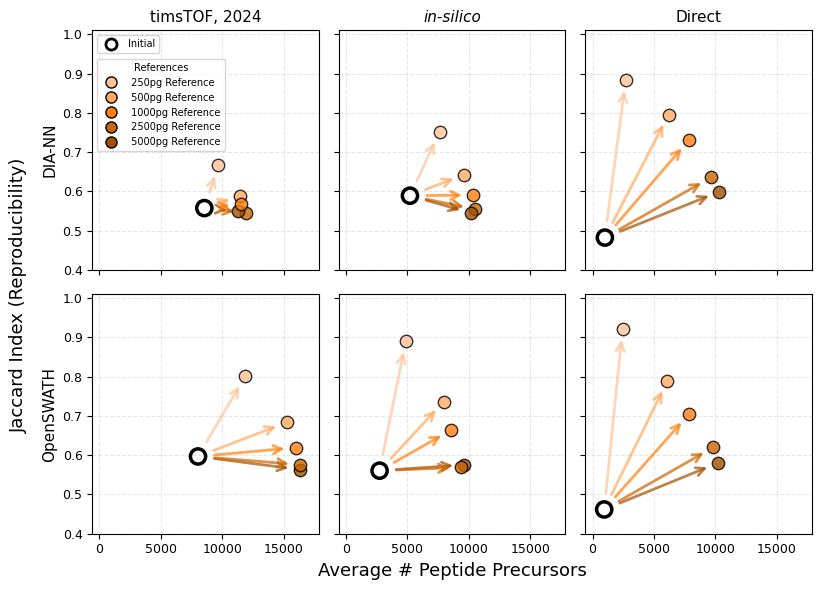

In [10]:
create_dilution_plot(tog_df)

In [11]:
tog_df

,Dilution Library,Library,Mean Identifications,Jaccard Index,# Identifications In Common,Software
0,Reconstructed (Reference = 2500pg),"timsTOF, 2024",11890.666667,0.545015,4847,DIA-NN
1,Reconstructed (Reference = 500pg),"timsTOF, 2024",11463.888889,0.588270,4939,DIA-NN
2,Reconstructed (Reference = 250pg),"timsTOF, 2024",9679.333333,0.666092,4817,DIA-NN
3,Reconstructed (Reference = 5000pg),"timsTOF, 2024",11272.777778,0.549449,4666,DIA-NN
4,Reconstructed (Reference = 1000pg),"timsTOF, 2024",11507.111111,0.567067,4806,DIA-NN
5,Initial,"timsTOF, 2024",8538.666667,0.557119,3646,DIA-NN
6,Reconstructed (Reference = 2500pg),in-silico,10493.333333,0.554096,4328,DIA-NN
7,Reconstructed (Reference = 500pg),in-silico,9609.888889,0.642480,4538,DIA-NN
8,Reconstructed (Reference = 250pg),in-silico,7615.666667,0.750949,4424,DIA-NN
9,Reconstructed (Reference = 5000pg),in-silico,10169.333333,0.544706,4174,DIA-NN


In [12]:
percent_increase(2735, 4871)

78.09872029250458

In [13]:
percent_increase(2735, 9631)

252.13893967093236

In [14]:
percent_increase(0.56, 0.89)

58.928571428571416

In [15]:
percent_increase(0.56, 0.57)

1.7857142857142672

In [16]:
9631 / 2735

3.5213893967093237